# B2B Product Recommender — Data Processing & Split
## MML1 – Domácí úkol 2

**Projekt:** B2B doporučovací systém produktů (Lola Games)
**Autor:** Natalia Bobyleva
**Datum:** 2026-05-02

## 1. Navázání na DÚ1 — Task Framing

**Business problém:**
B2B zákazníci (velkoobchody, maloobchody, distributoři) nakupují intimní zboží od značky Lola Games. Obchodní zástupce potřebuje vědět, *které produkty nabídnout konkrétnímu zákazníkovi v příštím kvartálu*, aby zvýšil pravděpodobnost nákupu a snížil čas strávený hledáním relevantního sortimentu.

**Analytická úloha:**
Doporučovací (ranking) úloha — pro každý pár (zákazník × produkt) odhadneme binární relevanci a produkty seřadíme od nejrelevantnějšího.

**Jednotka pozorování:**
Jeden řádek = jeden kandidátní pár **zákazník × produkt × časové okno (kvartál)**.
Na základě zpětné vazby od učitele (feedback HW1) jsme jednotku přepracovali z "jedné transakce" na "kandidátní doporučení", což umožňuje čisté definování targetu a top-K evaluaci.

**Cílová proměnná:**
`target_ordered` = 1, pokud zákazník daný produkt v daném kvartálu objednal; 0, pokud ne.

**Hlavní metrika:**
HitRate@10 — podíl zákazníků, pro něž alespoň jeden skutečně objednaný produkt figuruje v top-10 doporučeních.
Doplňkově: Precision@10, Recall@10.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings, os

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
np.random.seed(42)

## 2. Popis dat

Vstupní data tvoří čtyři tabulky uložené ve složce `b2b_recommender_tables_csv/`:

| Soubor | Popis |
|--------|-------|
| `customers.csv` | 100 B2B zákazníků — atributy obchodu |
| `products.csv` | 459 produktů — kolekce, kategorie, dostupnost po kvartálech |
| `orders.csv` | Řádkové položky objednávek za 2025 |
| `training_table.csv` | Finální ML tabulka: kandidátní páry zákazník×produkt×kvartál s předpočítanými features |

Centrální tabulka pro modelování je `training_table.csv`.

In [2]:
DATA_DIR = "b2b_recommender_tables_csv"

customers = pd.read_csv(f"{DATA_DIR}/customers.csv")
products  = pd.read_csv(f"{DATA_DIR}/products.csv")
orders    = pd.read_csv(f"{DATA_DIR}/orders.csv")
df        = pd.read_csv(f"{DATA_DIR}/training_table.csv")

print("customers:", customers.shape)
print("products: ", products.shape)
print("orders:   ", orders.shape)
print("training_table:", df.shape)

customers: (100, 11)
products:  (459, 22)
orders:    (5841, 11)
training_table: (127400, 27)


In [3]:
print("=== training_table — prvních 3 řádky ===")
df.head(3)

=== training_table — prvních 3 řádky ===


,customer_id,period,product_id,available_in_period,is_new_in_period,price_eur,collection,category,target_segment,is_realistic,customer_type,store_focus,women_only,queer_friendly,sells_realistic,newness_affinity,private_label_conflict,blocked_collection_conflict,fits_store_profile,prior_product_orders,prior_product_units,prior_category_orders,prior_collection_orders,product_popularity_prev,target_ordered,target_units,target_order_lines
0,10872248,2025Q1,1018-01lola,1,0,26.3,Lola Games Wand,vibrator,unisex,0,retailer,mixed,0,1,1,0.5,1,0,1,0,0,0,0,0.0,0,0,0
1,10872248,2025Q1,1018-02lola,1,0,26.3,Lola Games Wand,vibrator,unisex,0,retailer,mixed,0,1,1,0.5,1,0,1,0,0,0,0,0.0,0,0,0
2,10872248,2025Q1,1018-03lola,1,0,26.3,Lola Games Wand,vibrator,unisex,0,retailer,mixed,0,1,1,0.5,1,0,1,0,0,0,0,0.0,0,0,0


In [4]:
print("=== Počty kvartálů ===")
print(df["period"].value_counts().sort_index())

print("\n=== Chybějící hodnoty ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "  Žádné chybějící hodnoty.")

print("\n=== Duplicitní řádky ===")
dupl = df.duplicated(subset=["customer_id","period","product_id"]).sum()
print(f"  Duplicitních párů (customer, period, product): {dupl}")

print("\n=== Distribuce targetu ===")
tc = df["target_ordered"].value_counts()
print(tc)
print(f"  Kladný podíl: {df['target_ordered'].mean():.4f} ({df['target_ordered'].mean()*100:.2f} %)")

=== Počty kvartálů ===
period
2025Q1    45300
2025Q2    35000
2025Q3    26300
2025Q4    20800
Name: count, dtype: int64

=== Chybějící hodnoty ===
  Žádné chybějící hodnoty.

=== Duplicitní řádky ===
  Duplicitních párů (customer, period, product): 0

=== Distribuce targetu ===
target_ordered
0    122180
1      5220
Name: count, dtype: int64
  Kladný podíl: 0.0410 (4.10 %)


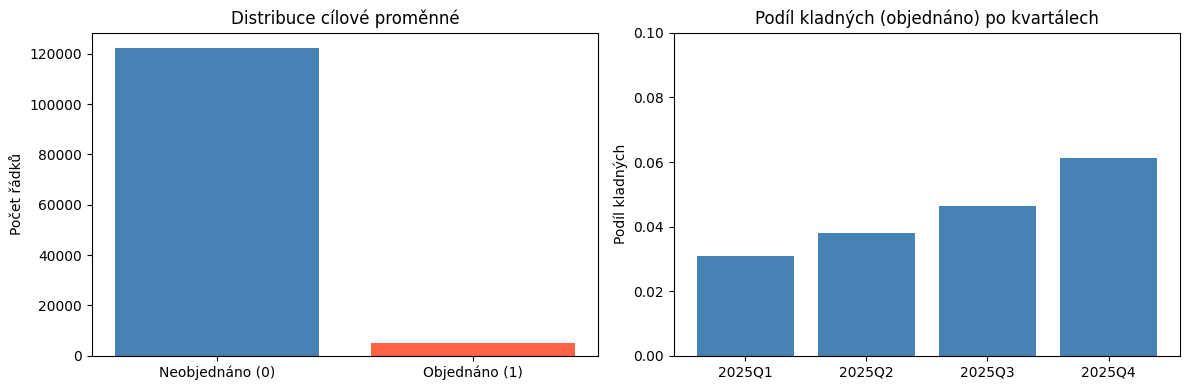

Graf uložen jako target_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
axes[0].bar(["Neobjednáno (0)", "Objednáno (1)"],
            df["target_ordered"].value_counts().sort_index().values,
            color=["steelblue","tomato"])
axes[0].set_title("Distribuce cílové proměnné")
axes[0].set_ylabel("Počet řádků")

# Positive rate per period
pos_rate = df.groupby("period")["target_ordered"].mean()
axes[1].bar(pos_rate.index, pos_rate.values, color="steelblue")
axes[1].set_title("Podíl kladných (objednáno) po kvartálech")
axes[1].set_ylabel("Podíl kladných")
axes[1].set_ylim(0, 0.1)

plt.tight_layout()
plt.savefig("target_distribution.png", dpi=100)
plt.show()
print("Graf uložen jako target_distribution.png")

In [6]:
print("=== Zákazníci — typy ===")
print(customers["customer_type"].value_counts())
print("\n=== Produkty — kategorie ===")
print(products["category"].value_counts())
print("\n=== Produkty — kolekce (top 10) ===")
print(products["collection"].value_counts().head(10))

=== Zákazníci — typy ===
customer_type
retailer       59
wholesaler     23
distributor    18
Name: count, dtype: int64

=== Produkty — kategorie ===
category
other                  115
anal                   107
masturbator             74
dildo                   56
vibrator                33
vaginal_balls           23
bdsm                    15
clitoral_stimulator     15
vacuum_pump             14
lubricant                3
egg_vibrator             3
nipple_toy               1
Name: count, dtype: int64

=== Produkty — kolekce (top 10) ===
collection
Lola Games Party Hard                            39
Lola Games Pure Passion                          37
Lola games Satisfaction                          36
Lola games Spice It Up                           35
Lola games First Time                            28
Lola Games Marshmallow                           26
Lola Games Flow                                  20
Lola games Love Story                            20
Lola Games Back Door Collect

## 3. Leakage Audit

Leakage nastává, pokud model vid informaci, která by v okamžiku reálné predikce nebyla dostupná.

### Identifikované rizika a jejich řešení:

| Proměnná / krok | Riziko | Řešení |
|-----------------|--------|--------|
| `target_ordered`, `target_units`, `target_order_lines` | **Přímý target** — nesmí být feature | Vyjmuty z feature setu |
| `period` | Časová informace — pokud by model "viděl" číslo kvartálu, mohl by jej zneužít k přiřazení pozic | Použit **pouze ke splitu**, ne jako feature |
| `prior_product_orders`, `prior_product_units`, `prior_category_orders`, `prior_collection_orders`, `product_popularity_prev` | Mohly by obsahovat data z budoucnosti | Ověřeno: prefix "prior" = vypočítáno z *předchozích* kvartálů; pro Q2 row → počítáno z Q1; pro Q3 row → z Q1+Q2. **Bezpečné.** |
| `blocked_collection_conflict`, `fits_store_profile` | Odvozené proměnné — mohly by kódovat target | Derivovány z atributů zákazníka a produktu (ne z objednávek). **Bezpečné.** |
| Fitování scaleru / encoderu | Fit na všech datech by prozradil statistiky z validace/testu | Scaler a encoder **fitovány pouze na train** sadě |

### Random split jako metodická chyba:
Náhodné promíchání řádků by způsobilo leakage, protože:
- řádky z Q3 (kde `prior_*` zahrnují Q1+Q2 historii) by mohly být v train sadě,
- zatímco odpovídající zákazníkovy Q2 řádky v validaci — model by "viděl budoucnost".

In [7]:
# Ověření: prior_* features jsou v Q1 vesměs nulové (žádná předchozí historie)
q1 = df[df["period"] == "2025Q1"]
prior_cols = ["prior_product_orders", "prior_product_units",
              "prior_category_orders", "prior_collection_orders",
              "product_popularity_prev"]

print("=== Průměry prior_* features po kvartálech ===")
print(df.groupby("period")[prior_cols].mean().round(4))
print()
print("Komentář: v Q1 jsou prior_* features téměř nulové (nová data),")
print("  v Q2 zachycují Q1 historii, v Q3 historii Q1+Q2 atd.")
print("  => Žádný leakage z budoucnosti.")

=== Průměry prior_* features po kvartálech ===
        prior_product_orders  prior_product_units  prior_category_orders  \
period                                                                     
2025Q1                0.0000               0.0000                 0.0000   
2025Q2                0.0344               0.1082                 2.0158   
2025Q3                0.0766               0.2389                 3.9837   
2025Q4                0.1186               0.3625                 5.7504   

        prior_collection_orders  product_popularity_prev  
period                                                    
2025Q1                   0.0000                   0.0000  
2025Q2                   0.6815                   0.0318  
2025Q3                   1.3281                   0.0700  
2025Q4                   1.8461                   0.1080  

Komentář: v Q1 jsou prior_* features téměř nulové (nová data),
  v Q2 zachycují Q1 historii, v Q3 historii Q1+Q2 atd.
  => Žádný leakage z bu

## 4. Návrh splitu

### Logika splitu: časový (chronologický)

Tento projekt je doporučovací systém nad B2B historií objednávek.
**Produkční scénář:** na začátku každého kvartálu chceme doporučit zákazníkovi produkty na základě jeho dosavadního chování (minulé kvartály) a atributů zákazníka/produktu.

**Proč temporální split, ne náhodný:**
- Cada řádek pro kvartál Q obsahuje `prior_*` features vypočítané z kvartálů < Q
- Náhodné promíchání by způsobilo data leakage (model by viděl „budoucí" historii)
- Temporální split simuluje reálné nasazení: učíme se na starých datech, validujeme na nových

### Zvolené rozdělení:

| Sada | Kvartály | Řádků | Podíl |
|------|----------|-------|-------|
| **Train** | 2025Q1 + 2025Q2 | 80 300 | 63 % |
| **Validation** | 2025Q3 | 26 300 | 21 % |
| **Test** | 2025Q4 | 20 800 | 16 % |

**Proč Q1+Q2 jako train:**
Q1 obsahuje zákazníky s nulovou historií (první kvartál); Q2 přidává zákazníky s jedním kvartálem zkušeností. Kombinace dává modelu vzorek chování v různých fázích onboardingu.

**Test set** se v tomto úkolu nepoužívá — zůstává stranou pro finální evaluaci v HW4/HW5.

In [8]:
train_raw = df[df["period"].isin(["2025Q1","2025Q2"])].copy()
val_raw   = df[df["period"] == "2025Q3"].copy()
test_raw  = df[df["period"] == "2025Q4"].copy()

print(f"Train:      {len(train_raw):>6} řádků | pozitivní: {train_raw['target_ordered'].mean():.4f}")
print(f"Validation: {len(val_raw):>6} řádků | pozitivní: {val_raw['target_ordered'].mean():.4f}")
print(f"Test:       {len(test_raw):>6} řádků | pozitivní: {test_raw['target_ordered'].mean():.4f}")
print()
print("Počet zákazníků v train:", train_raw["customer_id"].nunique())
print("Počet zákazníků v val:  ", val_raw["customer_id"].nunique())
print("Počet zákazníků v test: ", test_raw["customer_id"].nunique())

Train:       80300 řádků | pozitivní: 0.0339
Validation:  26300 řádků | pozitivní: 0.0464
Test:        20800 řádků | pozitivní: 0.0613

Počet zákazníků v train: 100
Počet zákazníků v val:   100
Počet zákazníků v test:  100


In [9]:
# Ověření: žádný zákazník-produkt-kvartál pár není ve více sadách
overlap_tv = pd.merge(
    train_raw[["customer_id","product_id","period"]],
    val_raw[["customer_id","product_id","period"]],
    on=["customer_id","product_id","period"])
overlap_vt = pd.merge(
    val_raw[["customer_id","product_id","period"]],
    test_raw[["customer_id","product_id","period"]],
    on=["customer_id","product_id","period"])

print(f"Překryv train ∩ validation: {len(overlap_tv)} řádků (mělo by být 0)")
print(f"Překryv validation ∩ test:  {len(overlap_vt)} řádků (mělo by být 0)")

Překryv train ∩ validation: 0 řádků (mělo by být 0)
Překryv validation ∩ test:  0 řádků (mělo by být 0)


## 5. Preprocessing pipeline

### Definice feature skupin

Fitování veškerých transformací probíhá **pouze na train sadě**. Na validaci a test aplikujeme `transform()`.

| Typ | Sloupce | Transformace |
|-----|---------|--------------|
| ID (zachovat pro evaluaci) | `customer_id`, `product_id`, `period` | — |
| Target | `target_ordered`, `target_units`, `target_order_lines` | — |
| Binární | `available_in_period`, `is_new_in_period`, `is_realistic`, `women_only`, `queer_friendly`, `sells_realistic`, `private_label_conflict`, `blocked_collection_conflict`, `fits_store_profile` | beze změny |
| Kategoriální | `collection`, `category`, `target_segment`, `customer_type`, `store_focus` | LabelEncoder |
| Numerické | `price_eur`, `newness_affinity`, `prior_product_orders`, `prior_product_units`, `prior_category_orders`, `prior_collection_orders`, `product_popularity_prev` | StandardScaler (fit na train) |

**Pozn. k LabelEncoder pro `collection`:** Kolekce má 32 unikátních hodnot. One-hot encoding by přidal 32 sloupců; pro jednoduchý benchmark je Label Encoding dostačující. V navazujícím modelování zvážíme target encoding nebo embedding.

In [10]:
ID_COLS      = ["customer_id", "product_id", "period"]
TARGET_COLS  = ["target_ordered", "target_units", "target_order_lines"]
BINARY_COLS  = ["available_in_period", "is_new_in_period", "is_realistic",
                "women_only", "queer_friendly", "sells_realistic",
                "private_label_conflict", "blocked_collection_conflict", "fits_store_profile"]
CAT_COLS     = ["collection", "category", "target_segment", "customer_type", "store_focus"]
NUM_COLS     = ["price_eur", "newness_affinity",
                "prior_product_orders", "prior_product_units",
                "prior_category_orders", "prior_collection_orders",
                "product_popularity_prev"]

all_feature_cols = BINARY_COLS + CAT_COLS + NUM_COLS
print(f"Celkem features: {len(all_feature_cols)}")
print(f"  Binární:      {len(BINARY_COLS)}")
print(f"  Kategoriální: {len(CAT_COLS)}")
print(f"  Numerické:    {len(NUM_COLS)}")

Celkem features: 21
  Binární:      9
  Kategoriální: 5
  Numerické:    7


In [11]:
def preprocess(train, val, test, cat_cols, num_cols):
    """Fit encoders/scaler on train, transform all three splits."""
    train, val, test = train.copy(), val.copy(), test.copy()

    # --- Label encoding (fit on train) ---
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col].astype(str))
        # Handle unseen labels in val/test gracefully
        known = set(le.classes_)
        val[col]  = val[col].astype(str).apply(lambda x: x if x in known else le.classes_[0])
        test[col] = test[col].astype(str).apply(lambda x: x if x in known else le.classes_[0])
        val[col]  = le.transform(val[col])
        test[col] = le.transform(test[col])
        encoders[col] = le

    # --- Standard scaling (fit on train) ---
    scaler = StandardScaler()
    train[num_cols] = scaler.fit_transform(train[num_cols])
    val[num_cols]   = scaler.transform(val[num_cols])
    test[num_cols]  = scaler.transform(test[num_cols])

    return train, val, test, encoders, scaler

train_proc, val_proc, test_proc, encoders, scaler = preprocess(
    train_raw, val_raw, test_raw, CAT_COLS, NUM_COLS)

print("Preprocessing hotov.")
print("Train shape:", train_proc.shape)
print("Val shape:  ", val_proc.shape)
print("Test shape: ", test_proc.shape)

Preprocessing hotov.


Train shape: (80300, 27)
Val shape:   (26300, 27)
Test shape:  (20800, 27)


In [12]:
print("=== Kontrola: numerické features po standardizaci (train mean ≈ 0, std ≈ 1) ===")
print(train_proc[NUM_COLS].describe().loc[["mean","std"]].round(3))
print()
print("=== Kontrola: numerické features na val sadě (mean ≠ 0 je v pořádku) ===")
print(val_proc[NUM_COLS].describe().loc[["mean","std"]].round(3))

=== Kontrola: numerické features po standardizaci (train mean ≈ 0, std ≈ 1) ===
      price_eur  newness_affinity  prior_product_orders  prior_product_units  \
mean       -0.0               0.0                  -0.0                 -0.0   
std         1.0               1.0                   1.0                  1.0   

      prior_category_orders  prior_collection_orders  product_popularity_prev  
mean                    0.0                      0.0                     -0.0  
std                     1.0                      1.0                      1.0  

=== Kontrola: numerické features na val sadě (mean ≠ 0 je v pořádku) ===


      price_eur  newness_affinity  prior_product_orders  prior_product_units  \
mean      0.083               0.0                 0.467                0.418   
std       1.067               1.0                 2.423                2.437   

      prior_category_orders  prior_collection_orders  product_popularity_prev  
mean                  1.763                    1.301                    2.456  
std                   2.235                    2.309                    2.308  

## 6. Uložení datasetů

Uložíme dvě verze každé sady:
- **raw** — originální hodnoty (pro snadnou inspekci a popularity baseline)
- **processed** — po encoding a scaling (pro ML benchmark)

In [13]:
os.makedirs("data/train",      exist_ok=True)
os.makedirs("data/validation", exist_ok=True)
os.makedirs("data/test",       exist_ok=True)

# Raw splits
train_raw.to_csv("data/train/train_raw.csv",           index=False)
val_raw.to_csv("data/validation/validation_raw.csv",   index=False)
test_raw.to_csv("data/test/test_raw.csv",              index=False)

# Processed splits
train_proc.to_csv("data/train/train_processed.csv",           index=False)
val_proc.to_csv("data/validation/validation_processed.csv",   index=False)
test_proc.to_csv("data/test/test_processed.csv",              index=False)

print("Datasety uloženy:")
for f in ["data/train/train_raw.csv","data/train/train_processed.csv",
          "data/validation/validation_raw.csv","data/validation/validation_processed.csv",
          "data/test/test_raw.csv","data/test/test_processed.csv"]:
    size = os.path.getsize(f)
    print(f"  {f:55s} {size:>8,} B")

Datasety uloženy:
  data/train/train_raw.csv                                10,266,866 B
  data/train/train_processed.csv                          16,417,078 B
  data/validation/validation_raw.csv                      3,373,727 B
  data/validation/validation_processed.csv                5,307,939 B
  data/test/test_raw.csv                                  2,667,359 B
  data/test/test_processed.csv                            4,185,711 B


## 7. Shrnutí

**Co se ukázalo jako metodicky důležité:**
- Klíčové rozhodnutí bylo zvolení **temporálního splitu** místo náhodného. Náhodný split by u tohoto projektu vedl k data leakage, protože `prior_*` features jsou vypočítány z předchozích kvartálů — jejich přítomnost v train při validaci na dřívějším kvartálu by způsobila optimistické zkreslení výkonu.
- **Jednotka pozorování** musela být upřesněna na *zákazník × produkt × kvartál* (na základě zpětné vazby z HW1), aby bylo možné čistě definovat binární target a provést top-K evaluaci.
- `prior_*` features jsou safe (neprostupují data z budoucnosti), ale je třeba to explicitně ověřit — ukázalo se, že v Q1 jsou skutečně nulové.

**Co bylo obtížné:**
- Třída 1 (objednáno) tvoří jen ~4 % dat — silná class imbalance. Pro benchmark to znamená, že accuracy by byla zavádějící metrikou; HitRate@K je vhodnější.
- Collection encoding: 32 hodnot — LabelEncoder je rychlý kompromis pro benchmark, ale v produkčním modelu bychom zvolili sofistikovanější přístup (target encoding, learnable embedding).

**Další krok v navazujícím modelování:**
- Zkusit content-based model (cosine similarity zákazník-produkt profilu)
- Vyzkoušet LightGBM s rank loss (LambdaRank)
- Přidat business rules jako hard filter (blocked_collection_conflict = 1 → automaticky 0 skóre)
- Zvážit weighting pozitivních příkladů pro kompenzaci class imbalance